In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)

print("Imports OK")

Imports OK


In [2]:
# --- Load the named-drug PDE file ---

pde_named = pd.read_csv("dataSets/DE1_0_2008_to_2010_Prescription_Drug_Events_KNOWN_DRUGS_ONLY.csv")
pde = pd.read_csv("dataSets/DE1_0_2008_to_2010_Prescription_Drug_Events_Sample_1.csv")

print("Shape:", pde_named.shape)
print("\nColumns:", list(pde_named.columns))
display(pde_named.head())

C:\Users\Murali krishna M\AppData\Local\Temp\ipykernel_28956\3557670481.py:4: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  pde = pd.read_csv("dataSets/DE1_0_2008_to_2010_Prescription_Drug_Events_Sample_1.csv")


Shape: (954814, 9)

Columns: ['DESYNPUF_ID', 'PDE_ID', 'SRVC_DT', 'PROD_SRVC_ID', 'QTY_DSPNSD_NUM', 'DAYS_SUPLY_NUM', 'PTNT_PAY_AMT', 'TOT_RX_CST_AMT', 'DRUG_NAME']


,DESYNPUF_ID,PDE_ID,SRVC_DT,PROD_SRVC_ID,QTY_DSPNSD_NUM,DAYS_SUPLY_NUM,PTNT_PAY_AMT,TOT_RX_CST_AMT,DRUG_NAME
0,00013D2EFD8E45D1,233664490397622,20080103,247037252,30.0,20,10.0,120.0,PROZAC 20 MG PULVULE
1,00013D2EFD8E45D1,233574491083209,20080123,179180672,30.0,30,0.0,240.0,EFFEXOR TABLETS
2,00013D2EFD8E45D1,233254492355736,20080214,254511335,60.0,30,0.0,10.0,PROPOXYPHENE NAPSYLATE ACETAMINOPHEN TABLETS F...
3,00013D2EFD8E45D1,233234488805472,20080306,49999063260,30.0,30,0.0,20.0,PAROXETINE HCL 20 MG TABLET
4,00013D2EFD8E45D1,233484489743981,20080317,904233480,10.0,30,0.0,10.0,SERPAZIDE TABLETS


In [3]:
beneficiary_2008 = pd.read_csv("dataSets/DE1_0_2008_Beneficiary_Summary_File_Sample_1.csv")
bene = beneficiary_2008.copy()
# Convert date columns from YYYYMMDD number to real dates
bene['BENE_BIRTH_DT'] = pd.to_datetime(bene['BENE_BIRTH_DT'], format='%Y%m%d')
bene['BENE_DEATH_DT'] = pd.to_datetime(bene['BENE_DEATH_DT'], format='%Y%m%d')
print(bene['BENE_BIRTH_DT'].dtype)
print(bene['BENE_DEATH_DT'].dtype)# Convert date columns from YYYYMMDD number to real dates
bene['BENE_BIRTH_DT'] = pd.to_datetime(bene['BENE_BIRTH_DT'], format='%Y%m%d')
bene['BENE_DEATH_DT'] = pd.to_datetime(bene['BENE_DEATH_DT'], format='%Y%m%d')
print(bene['BENE_BIRTH_DT'].dtype)
print(bene['BENE_DEATH_DT'].dtype)
# Calculate age as of 2008 (reference year for this file)
bene['AGE'] = 2008 - bene['BENE_BIRTH_DT'].dt.year
print(bene[['AGE', 'BENE_BIRTH_DT']].head(3))
# Fix chronic condition columns: 1 = has condition, 2 = does not -> convert to 1/0
chronic_cols = ['SP_ALZHDMTA', 'SP_CHF', 'SP_CHRNKIDN', 'SP_CNCR', 'SP_COPD',
                 'SP_DEPRESSN', 'SP_DIABETES', 'SP_ISCHMCHT', 'SP_OSTEOPRS',
                 'SP_RA_OA', 'SP_STRKETIA']

for col in chronic_cols:
    bene[col] = bene[col].map({1: 1, 2: 0})
# Filter to patients with full-year Part D coverage
bene_full_coverage = bene[bene['PLAN_CVRG_MOS_NUM'] == 12].copy()
print("\nPatients with full Part D coverage:", len(bene_full_coverage))
# Keep only the columns we actually need going forward
keep_cols = ['DESYNPUF_ID', 'AGE', 'BENE_SEX_IDENT_CD', 'BENE_RACE_CD',
             'BENE_DEATH_DT'] + chronic_cols

bene_clean = bene_full_coverage[keep_cols].copy()

print("\nCleaned Beneficiary table shape:", bene_clean.shape)
display(bene_clean.head())

datetime64[ns]
datetime64[ns]
datetime64[ns]
datetime64[ns]
   AGE BENE_BIRTH_DT
0   85    1923-05-01
1   65    1943-01-01
2   72    1936-09-01

Patients with full Part D coverage: 61870

Cleaned Beneficiary table shape: (61870, 16)


,DESYNPUF_ID,AGE,BENE_SEX_IDENT_CD,BENE_RACE_CD,BENE_DEATH_DT,SP_ALZHDMTA,SP_CHF,SP_CHRNKIDN,SP_CNCR,SP_COPD,SP_DEPRESSN,SP_DIABETES,SP_ISCHMCHT,SP_OSTEOPRS,SP_RA_OA,SP_STRKETIA
0,00013D2EFD8E45D1,85,1,1,NaT,0,0,0,0,0,0,0,0,0,0,0
2,0001FDD721E223DC,72,2,1,NaT,0,0,0,0,0,0,0,0,0,0,0
9,00036A21B65B0206,70,2,2,NaT,0,0,0,0,0,0,0,0,0,0,0
10,000489E7EAAD463F,74,2,1,NaT,0,0,0,0,0,1,1,1,0,0,0
12,0004F0ABD505251D,72,2,1,NaT,1,0,0,1,1,0,1,1,0,0,0


In [4]:
# --- Date sanity check (learned from the other team's corrupted-date issue) ---

pde_named['SRVC_DT'] = pd.to_datetime(pde_named['SRVC_DT'], format='%Y%m%d', errors='coerce')

print("Date range:", pde_named['SRVC_DT'].min(), "to", pde_named['SRVC_DT'].max())

valid_range = (pde_named['SRVC_DT'] >= '2008-01-01') & (pde_named['SRVC_DT'] <= '2010-12-31')
bad_dates = (~valid_range).sum()
print(f"Rows with corrupted/out-of-range dates: {bad_dates}")

pde_named = pde_named[valid_range].copy()
print("Shape after date filter:", pde_named.shape)

print("\nUnique drug names:", pde_named['DRUG_NAME'].nunique())
print(pde_named['DRUG_NAME'].value_counts().head(10))

Date range: 2008-01-01 00:00:00 to 2010-12-31 00:00:00
Rows with corrupted/out-of-range dates: 0
Shape after date filter: (954814, 9)

Unique drug names: 6846
DRUG_NAME
LISINOPRIL TABLETS                 14752
SIMVASTATIN TABLETS                13105
LOVASTATIN TABLETS                  9242
LEVOTHYROXINE SODIUM TABLETS        6061
AMITRIPTYLINE HCL 25 MG TAB         6008
METFORMIN HYDROCHLORIDE TABLETS     5037
AGGRENOX CAPSULE                    5025
AMITRIPTYLINE HCL 10 MG TAB         4997
AMITRIPTYLINE HCL 50 MG TAB         4787
SYNTHROID TABLETS                   4672
Name: count, dtype: int64


In [5]:
# --- Normalize to base drug name (strip dosage/form info) ---

# Take the first word as a rough base-drug key
pde_named['DRUG_BASE'] = pde_named['DRUG_NAME'].str.split().str[0]

print("Unique base drug names:", pde_named['DRUG_BASE'].nunique())
print("\nSample: how AMITRIPTYLINE variants collapse together")
print(pde_named[pde_named['DRUG_BASE'] == 'AMITRIPTYLINE']['DRUG_NAME'].unique())

# Check overall repetition improvement -- this is the number that matters
fills_per_patient_drug = pde_named.groupby(['DESYNPUF_ID', 'DRUG_BASE']).size()
print("\nDistribution of fills per (patient, base drug):")
print(fills_per_patient_drug.describe())

at_least_3 = (fills_per_patient_drug >= 3).sum()
total_pairs = len(fills_per_patient_drug)
print(f"\n(patient, drug) pairs with 3+ fills: {at_least_3} out of {total_pairs} ({at_least_3/total_pairs*100:.1f}%)")

Unique base drug names: 2601

Sample: how AMITRIPTYLINE variants collapse together
['AMITRIPTYLINE HCL 25 MG TAB' 'AMITRIPTYLINE HCL 10 MG TAB'
 'AMITRIPTYLINE HCL 100 MG TAB' 'AMITRIPTYLINE HYDROCHLORIDE TABLETS'
 'AMITRIPTYLINE HCL 50 MG TAB' 'AMITRIPTYLINE HCL 150 MG TAB'
 'AMITRIPTYLINE HCL 75 MG TAB' 'AMITRIPTYLINE HCL TABLETS'
 'AMITRIPTYLINE HYDROCHLORIDE TABLETS USP' 'AMITRIPTYLINE 10 MG/ML VIAL'
 'AMITRIPTYLINE HCL TABLETS USP']

Distribution of fills per (patient, base drug):
count    897098.000000
mean          1.064336
std           0.293106
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          10.000000
dtype: float64

(patient, drug) pairs with 3+ fills: 6469 out of 897098 (0.7%)


In [6]:
# --- Option C: Patient-level 60-day gap, using FULL PDE data (not sparse named subset) ---

# Reload full PDE if needed (should already be in memory from earlier as `pde`)
pde['SRVC_DT'] = pd.to_datetime(pde['SRVC_DT'], format='%Y%m%d', errors='coerce')

# Date sanity check on full dataset too
valid_range = (pde['SRVC_DT'] >= '2008-01-01') & (pde['SRVC_DT'] <= '2010-12-31')
print("Corrupted dates in full PDE:", (~valid_range).sum())
pde_clean = pde[valid_range].copy()

# Sort by patient, then date -- essential for gap calculation
pde_clean = pde_clean.sort_values(['DESYNPUF_ID', 'SRVC_DT'])

# For each patient, find the gap between consecutive fills (ANY drug)
pde_clean['NEXT_FILL_DT'] = pde_clean.groupby('DESYNPUF_ID')['SRVC_DT'].shift(-1)
pde_clean['GAP_TO_NEXT_FILL'] = (pde_clean['NEXT_FILL_DT'] - pde_clean['SRVC_DT']).dt.days

print("\nGap distribution (any-drug, patient-level):")
print(pde_clean['GAP_TO_NEXT_FILL'].describe())

# Check the 60-day threshold specifically
gaps_valid = pde_clean['GAP_TO_NEXT_FILL'].dropna()
over_60 = (gaps_valid > 60).sum()
print(f"\nGaps > 60 days: {over_60} out of {len(gaps_valid)} ({over_60/len(gaps_valid)*100:.1f}%)")

Corrupted dates in full PDE: 0

Gap distribution (any-drug, patient-level):
count    5.452883e+06
mean     1.227808e+01
std      2.154307e+01
min      0.000000e+00
25%      3.000000e+00
50%      6.000000e+00
75%      1.400000e+01
max      7.860000e+02
Name: GAP_TO_NEXT_FILL, dtype: float64

Gaps > 60 days: 130525 out of 5452883 (2.4%)


In [7]:
# --- Build one clean snapshot per patient: features from first half, label from second half ---

cutoff_date = pd.Timestamp('2009-07-01')

# FEATURES: only use fills strictly BEFORE cutoff
pre_cutoff = pde_clean[pde_clean['SRVC_DT'] < cutoff_date]

patient_features_early = pre_cutoff.groupby('DESYNPUF_ID').agg(
    total_fills_early=('SRVC_DT', 'count'),
    avg_days_supply_early=('DAYS_SUPLY_NUM', 'mean'),
    avg_cost_burden_early=('PTNT_PAY_AMT', 'mean'),
    total_cost_burden_early=('PTNT_PAY_AMT', 'sum'),
    num_distinct_ndc_early=('PROD_SRVC_ID', 'nunique'),
    last_fill_date_early=('SRVC_DT', 'max'),
).reset_index()

# LABEL: was there ANY gap > 60 days entirely within the post-cutoff window?
post_cutoff = pde_clean[pde_clean['SRVC_DT'] >= cutoff_date].sort_values(['DESYNPUF_ID', 'SRVC_DT'])
post_cutoff['NEXT_FILL_DT'] = post_cutoff.groupby('DESYNPUF_ID')['SRVC_DT'].shift(-1)
post_cutoff['GAP'] = (post_cutoff['NEXT_FILL_DT'] - post_cutoff['SRVC_DT']).dt.days

label_df = post_cutoff.groupby('DESYNPUF_ID')['GAP'].max().reset_index()
label_df['DISCONTINUED'] = (label_df['GAP'] > 60).astype(int)

print("Patients with early-period features:", len(patient_features_early))
print("Patients with post-cutoff activity (labelable):", len(label_df))
print("\nLabel balance:")
print(label_df['DISCONTINUED'].value_counts(normalize=True))

Patients with early-period features: 83826
Patients with post-cutoff activity (labelable): 92949

Label balance:
DISCONTINUED
0    0.590797
1    0.409203
Name: proportion, dtype: float64


In [8]:
# --- Merge early features + label, keep only patients present in BOTH windows ---

model_df = patient_features_early.merge(label_df[['DESYNPUF_ID', 'DISCONTINUED']], on='DESYNPUF_ID', how='inner')

print("Patients with both early features AND a post-cutoff label:", len(model_df))
print("\nLabel balance in final cohort:")
print(model_df['DISCONTINUED'].value_counts(normalize=True))

# Merge in demographics/chronic conditions from bene_clean
model_df = model_df.merge(bene_clean, on='DESYNPUF_ID', how='inner')

print("\nFinal shape after merging demographics:", model_df.shape)
print(model_df.columns.tolist())

# Drop the raw date column, not usable as a model feature directly
model_df = model_df.drop(columns=['last_fill_date_early'])

display(model_df.head())

Patients with both early features AND a post-cutoff label: 77237

Label balance in final cohort:
DISCONTINUED
0    0.611404
1    0.388596
Name: proportion, dtype: float64

Final shape after merging demographics: (58147, 23)
['DESYNPUF_ID', 'total_fills_early', 'avg_days_supply_early', 'avg_cost_burden_early', 'total_cost_burden_early', 'num_distinct_ndc_early', 'last_fill_date_early', 'DISCONTINUED', 'AGE', 'BENE_SEX_IDENT_CD', 'BENE_RACE_CD', 'BENE_DEATH_DT', 'SP_ALZHDMTA', 'SP_CHF', 'SP_CHRNKIDN', 'SP_CNCR', 'SP_COPD', 'SP_DEPRESSN', 'SP_DIABETES', 'SP_ISCHMCHT', 'SP_OSTEOPRS', 'SP_RA_OA', 'SP_STRKETIA']


,DESYNPUF_ID,total_fills_early,avg_days_supply_early,avg_cost_burden_early,total_cost_burden_early,num_distinct_ndc_early,DISCONTINUED,AGE,BENE_SEX_IDENT_CD,BENE_RACE_CD,BENE_DEATH_DT,SP_ALZHDMTA,SP_CHF,SP_CHRNKIDN,SP_CNCR,SP_COPD,SP_DEPRESSN,SP_DIABETES,SP_ISCHMCHT,SP_OSTEOPRS,SP_RA_OA,SP_STRKETIA
0,00013D2EFD8E45D1,113,31.858407,13.185841,1490.0,113,0,85,1,1,NaT,0,0,0,0,0,0,0,0,0,0,0
1,0001FDD721E223DC,38,32.105263,14.736842,560.0,38,0,72,2,1,NaT,0,0,0,0,0,0,0,0,0,0,0
2,00036A21B65B0206,62,32.741935,7.419355,460.0,62,0,70,2,2,NaT,0,0,0,0,0,0,0,0,0,0,0
3,000489E7EAAD463F,45,33.777778,10.000000,450.0,45,0,74,2,1,NaT,0,0,0,0,0,1,1,1,0,0,0
4,0004F0ABD505251D,61,31.967213,7.540984,460.0,61,1,72,2,1,NaT,1,0,0,1,1,0,1,1,0,0,0


model Training

In [9]:
# --- Drop deceased patients (same reasoning as before -- tiny group, not meaningful as feature) ---
model_df = model_df[model_df['BENE_DEATH_DT'].isna()].copy()
model_df = model_df.drop(columns=['BENE_DEATH_DT'])

print("Final shape after dropping deceased:", model_df.shape)
print(model_df['DISCONTINUED'].value_counts(normalize=True))

Final shape after dropping deceased: (58147, 21)
DISCONTINUED
0    0.699623
1    0.300377
Name: proportion, dtype: float64


In [10]:
# --- Train/test split ---

feature_cols = ['total_fills_early', 'avg_days_supply_early', 'avg_cost_burden_early',
    'total_cost_burden_early', 'num_distinct_ndc_early',
    'AGE', 'BENE_SEX_IDENT_CD', 'BENE_RACE_CD',
    'SP_ALZHDMTA', 'SP_CHF', 'SP_CHRNKIDN', 'SP_CNCR', 'SP_COPD',
    'SP_DEPRESSN', 'SP_DIABETES', 'SP_ISCHMCHT', 'SP_OSTEOPRS',
    'SP_RA_OA', 'SP_STRKETIA']

X = model_df[feature_cols]
y = model_df['DISCONTINUED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())

Train shape: (46517, 19)
Test shape: (11630, 19)
Train positive rate: 0.3003848055549584
Test positive rate: 0.30034393809114357


In [11]:
# ============================================================
# TRAIN ALL 3 MODELS + ROC-AUC COMPARISON
# ============================================================

results = {}

# ------------------------------------------------------------
# 1. Logistic Regression (scaled)
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

lr.fit(X_train_scaled, y_train)

# Probability predictions
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

# ROC-AUC (threshold-independent)
results['Logistic Regression'] = roc_auc_score(
    y_test,
    y_prob_lr
)

# Classification threshold
lr_threshold = 0.8

y_pred_lr = (y_prob_lr >= lr_threshold).astype(int)


# ------------------------------------------------------------
# 2. Random Forest
# ------------------------------------------------------------

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

# Probability predictions
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# ROC-AUC
results['Random Forest'] = roc_auc_score(
    y_test,
    y_prob_rf
)

# Default threshold = 0.5
y_pred_rf = (y_prob_rf >= 0.5).astype(int)


# ------------------------------------------------------------
# 3. XGBoost
# ------------------------------------------------------------

scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

xgb.fit(X_train, y_train)

# Probability predictions
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# ROC-AUC
results['XGBoost'] = roc_auc_score(
    y_test,
    y_prob_xgb
)

# Default threshold = 0.5
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)


# ------------------------------------------------------------
# ROC-AUC COMPARISON
# ------------------------------------------------------------

print("=== ROC-AUC Comparison ===")

for name, auc in results.items():
    print(f"{name}: {auc:.4f}")

=== ROC-AUC Comparison ===
Logistic Regression: 0.8809
Random Forest: 0.8689
XGBoost: 0.8793


=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

    Adherent     0.8164    0.9463    0.8765      8137
Discontinued     0.8012    0.5042    0.6189      3493

    accuracy                         0.8135     11630
   macro avg     0.8088    0.7252    0.7477     11630
weighted avg     0.8118    0.8135    0.7992     11630



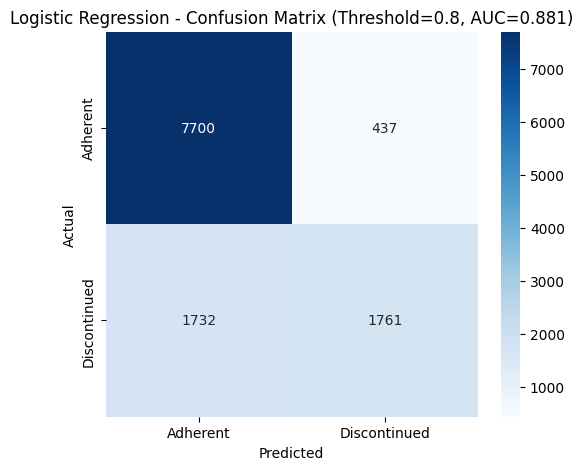

In [12]:

# ============================================================
# FULL EVALUATION - Logistic Regression
# ============================================================
print("=== Logistic Regression Classification Report ===")

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['Adherent', 'Discontinued'],
    digits=4
))

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Adherent', 'Discontinued'],
    yticklabels=['Adherent', 'Discontinued']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title(
    f'Logistic Regression - Confusion Matrix '
    f'(Threshold={lr_threshold}, AUC={results["Logistic Regression"]:.3f})'
)

plt.show()

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

    Adherent       0.84      0.90      0.87      8137
Discontinued       0.72      0.60      0.66      3493

    accuracy                           0.81     11630
   macro avg       0.78      0.75      0.76     11630
weighted avg       0.81      0.81      0.81     11630



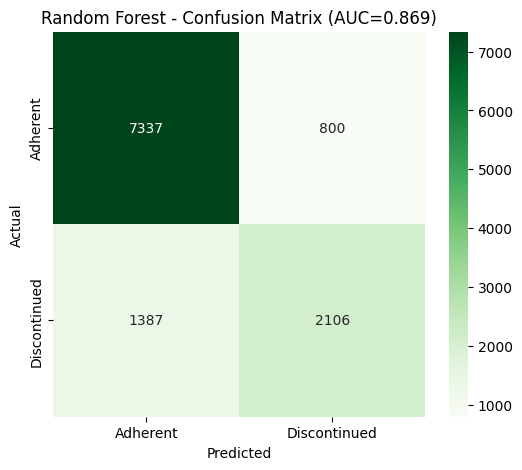


Random Forest Feature Importances:
total_fills_early          0.213873
num_distinct_ndc_early     0.194915
total_cost_burden_early    0.139576
avg_days_supply_early      0.112969
avg_cost_burden_early      0.101245
AGE                        0.097467
BENE_RACE_CD               0.018050
BENE_SEX_IDENT_CD          0.016354
SP_DIABETES                0.016231
SP_ISCHMCHT                0.013750
SP_DEPRESSN                0.011518
SP_CHF                     0.011101
SP_OSTEOPRS                0.010150
SP_ALZHDMTA                0.009845
SP_RA_OA                   0.008163
SP_CHRNKIDN                0.007526
SP_COPD                    0.007426
SP_CNCR                    0.005732
SP_STRKETIA                0.004109
dtype: float64


In [13]:
# ============================================================
# FULL EVALUATION - RANDOM FOREST
# ============================================================

y_pred_rf = rf.predict(X_test)

print("=== Random Forest Classification Report ===")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['Adherent', 'Discontinued']
))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Adherent', 'Discontinued'],
    yticklabels=['Adherent', 'Discontinued']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Random Forest - Confusion Matrix (AUC={results["Random Forest"]:.3f})')
plt.show()

# Feature Importance
rf_importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nRandom Forest Feature Importances:")
print(rf_importances)

=== XGBoost Classification Report ===
              precision    recall  f1-score   support

    Adherent       0.91      0.78      0.84      8137
Discontinued       0.61      0.81      0.70      3493

    accuracy                           0.79     11630
   macro avg       0.76      0.80      0.77     11630
weighted avg       0.82      0.79      0.80     11630



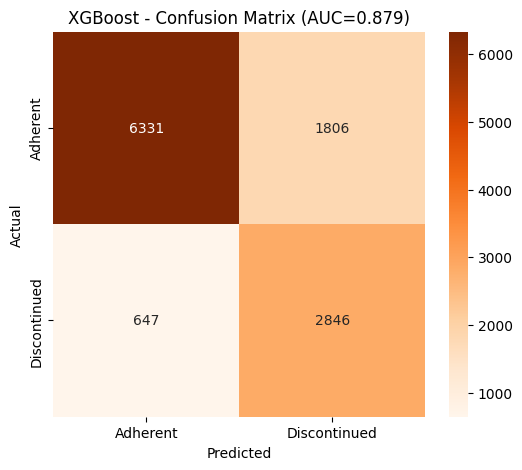


Feature importances:
total_fills_early          0.579705
num_distinct_ndc_early     0.176469
SP_CHRNKIDN                0.016714
BENE_RACE_CD               0.016016
SP_ALZHDMTA                0.015957
SP_STRKETIA                0.015941
SP_RA_OA                   0.015395
SP_ISCHMCHT                0.014900
SP_COPD                    0.014431
SP_DEPRESSN                0.014389
avg_cost_burden_early      0.014108
SP_DIABETES                0.014093
SP_OSTEOPRS                0.013649
avg_days_supply_early      0.013509
SP_CHF                     0.013242
AGE                        0.013222
total_cost_burden_early    0.013115
BENE_SEX_IDENT_CD          0.013034
SP_CNCR                    0.012110
dtype: float32


In [14]:
# --- Full evaluation for XGBoost (chosen for SHAP compatibility) ---

y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost Classification Report ===")
print(classification_report(y_test, y_pred_xgb, target_names=['Adherent', 'Discontinued']))

cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Adherent', 'Discontinued'], yticklabels=['Adherent', 'Discontinued'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'XGBoost - Confusion Matrix (AUC={results["XGBoost"]:.3f})')
plt.show()

# Feature importance
importances = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nFeature importances:")
print(importances)

                count       mean        std  min   25%   50%   75%    max
DISCONTINUED                                                             
0             40681.0  59.634965  28.712849  1.0  40.0  54.0  76.0  198.0
1             17466.0  25.155731  14.341071  1.0  15.0  23.0  34.0  107.0


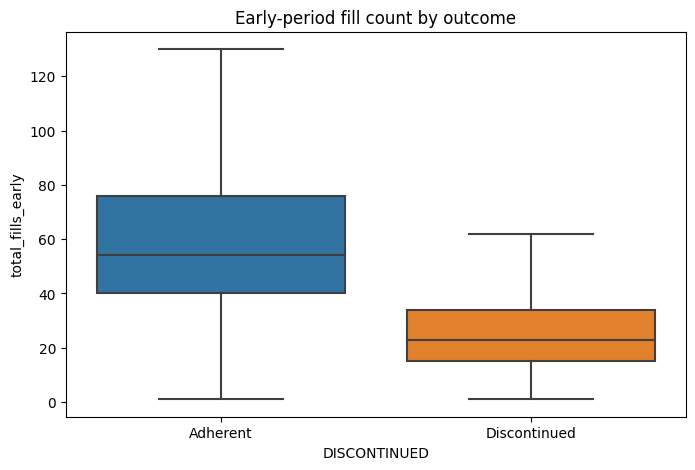

In [15]:
# Check if total_fills_early correlates suspiciously with just "how long were they observed"
correlation_check = model_df.groupby('DISCONTINUED')['total_fills_early'].describe()
print(correlation_check)

# Also check: does total_fills_early differ a lot between the two classes? (expected if real signal)
plt.figure(figsize=(8,5))
sns.boxplot(data=model_df, x='DISCONTINUED', y='total_fills_early', showfliers=False)
plt.xticks([0,1], ['Adherent', 'Discontinued'])
plt.title('Early-period fill count by outcome')
plt.show()

SHAP explainablity

In [16]:
# XGBoost's native SHAP calculation -- bypasses the shap library's TreeExplainer bug entirely
booster = xgb.get_booster()

import xgboost as xgb_module
dtest = xgb_module.DMatrix(X_test)

shap_values_raw = booster.predict(dtest, pred_contribs=True)

# Last column is the base value (expected value); drop it to get per-feature SHAP values
shap_values = shap_values_raw[:, :-1]
base_value = shap_values_raw[0, -1]

print("SHAP values shape:", shap_values.shape)
print("Base value:", base_value)

SHAP values shape: (11630, 19)
Base value: -0.00649975


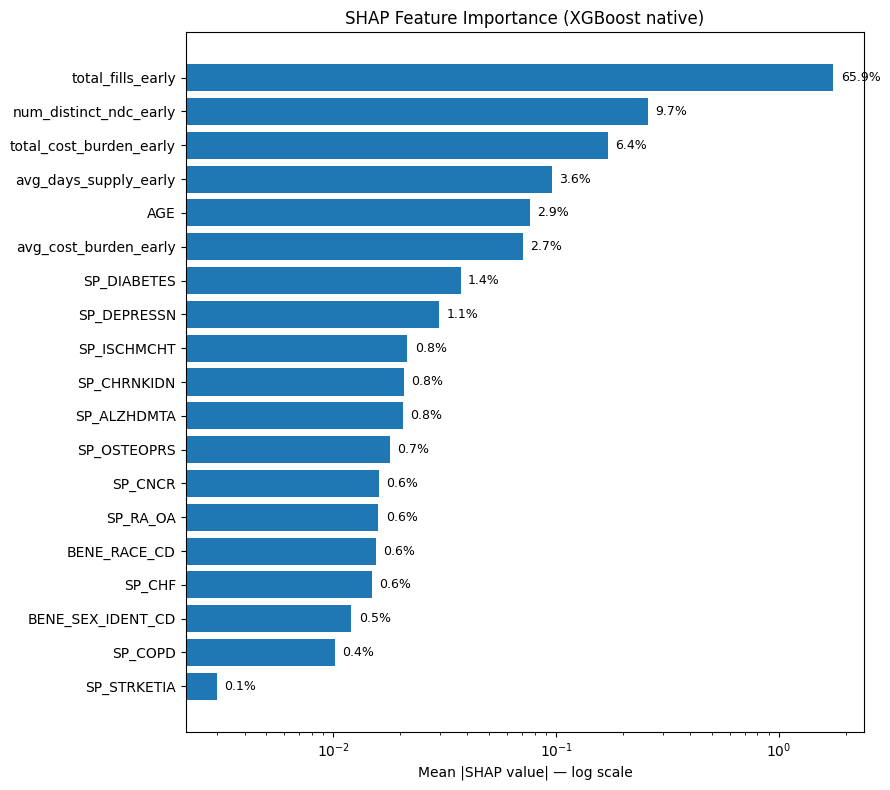

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Mean absolute SHAP value per feature
importance = np.abs(shap_values).mean(axis=0)

# Handle newer SHAP Explanation objects if necessary
if hasattr(shap_values, "values"):
    importance = np.abs(shap_values.values).mean(axis=0)

importance_pct = 100 * importance / importance.sum()

df_imp = pd.DataFrame({
    "feature": X_test.columns,
    "importance": importance,
    "importance_pct": importance_pct
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))

bars = ax.barh(
    df_imp["feature"],
    df_imp["importance"]
)

ax.set_xscale("log")
ax.set_xlabel("Mean |SHAP value| — log scale")
ax.set_title("SHAP Feature Importance (XGBoost native)")

# Add percentage labels
for bar, pct in zip(bars, df_imp["importance_pct"]):
    ax.text(
        bar.get_width() * 1.08,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

C:\Users\Murali krishna M\AppData\Local\Temp\ipykernel_28956\3134438736.py:37: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


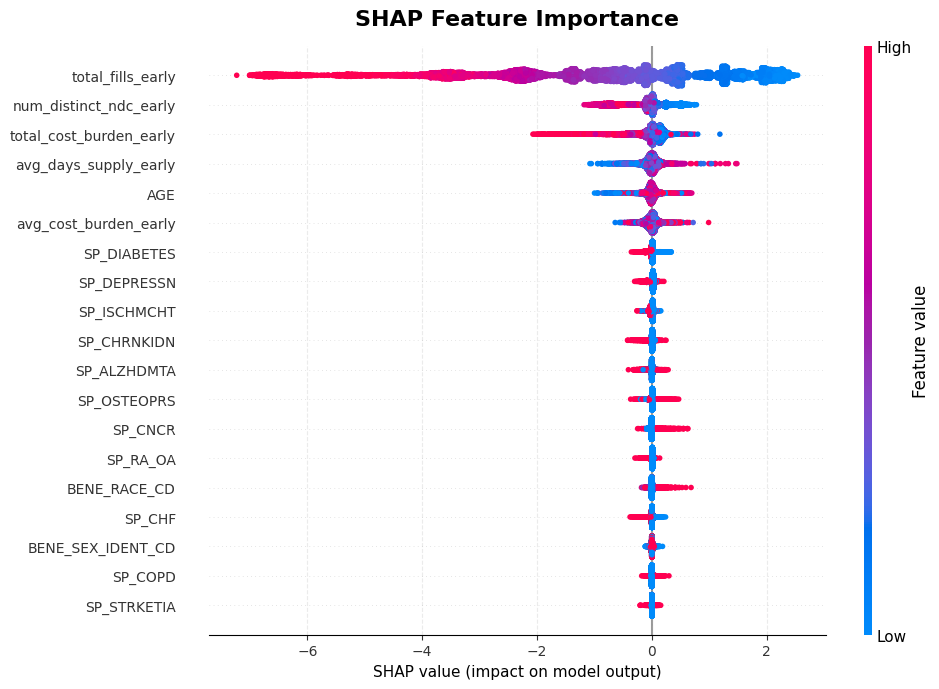

In [20]:
import shap
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_test,
    show=False,
    plot_size=None
)

# Styling
plt.title(
    "SHAP Feature Importance",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "SHAP value (impact on model output)",
    fontsize=11
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Clean up borders
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.grid(axis="x", linestyle="--", alpha=0.25)
plt.tight_layout()

plt.show()

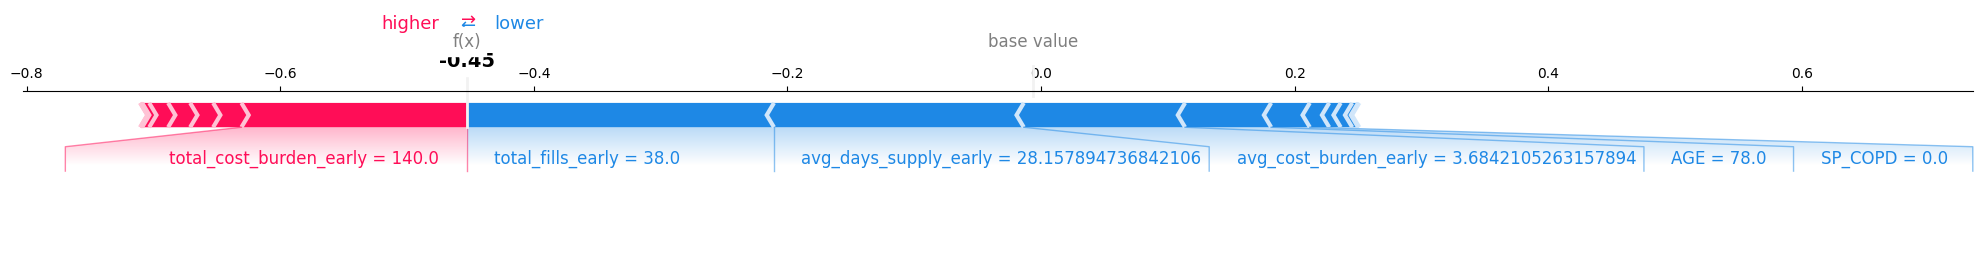

Actual outcome: 0
Predicted probability of discontinuation: 38.86%


In [24]:
# Individual patient explanation
sample_idx = 0

shap.force_plot(
    base_value,
    shap_values[sample_idx],
    X_test.iloc[sample_idx],
    matplotlib=True,
    show=False
)
plt.tight_layout()
plt.show()

print(f"Actual outcome: {y_test.iloc[sample_idx]}")
print(f"Predicted probability of discontinuation: {y_prob_xgb[sample_idx]:.2%}")

In [ ]:
"""
IMPORTANT: this is not run standalone. Copy-paste this cell into your
EXISTING notebook (NewDawn.ipynb), AFTER the cell where `xgb` (the trained
XGBClassifier) and `feature_cols` already exist in memory.

It saves everything the Flask backend needs to score new patients:
    model_artifacts/model.json              -- the trained XGBoost model
    model_artifacts/feature_columns.json    -- exact column order the model expects
    model_artifacts/risk_thresholds.json    -- tunable tier cutoffs

Run this once, then copy the whole `model_artifacts/` folder into the
backend project directory (or point EXPORT_DIR below directly at it).

import json
from pathlib import Path

EXPORT_DIR = Path("model_artifacts")   # change this path if needed
EXPORT_DIR.mkdir(exist_ok=True)

# 1. Save the trained model in XGBoost's native format
xgb.get_booster().save_model(str(EXPORT_DIR / "model.json"))
print(f"Saved model to {EXPORT_DIR / 'model.json'}")

# 2. Save the exact feature column order the model was trained on.
#    The backend MUST build its feature DataFrame in this exact order.
with open(EXPORT_DIR / "feature_columns.json", "w") as f:
    json.dump(list(X_train.columns), f, indent=2)
print(f"Saved feature column order to {EXPORT_DIR / 'feature_columns.json'}")

# 3. Save tunable risk-tier probability thresholds.
#    Adjust these numbers based on the predict_proba distribution on your
#    test set if you want tier sizes to look different in the demo --
#    this is a presentation choice, not a retraining decision.
thresholds = {"high": 0.60, "medium": 0.35}
with open(EXPORT_DIR / "risk_thresholds.json", "w") as f:
    json.dump(thresholds, f, indent=2)
print(f"Saved risk thresholds to {EXPORT_DIR / 'risk_thresholds.json'}")

print("\nDone. Copy the model_artifacts/ folder into the backend project.")"""


Saved model to model_artifacts\model.json
Saved feature column order to model_artifacts\feature_columns.json
Saved risk thresholds to model_artifacts\risk_thresholds.json

Done. Copy the model_artifacts/ folder into the backend project.
